In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

1. Đang dò tìm đường dẫn và tải dữ liệu...

--- THỐNG KÊ DỮ LIỆU BAN ĐẦU ---
Tổng số dòng và cột ban đầu: (67986, 8)

Kiểm tra dữ liệu thiếu (Null) ở từng cột:
asin                0
name                3
rating              0
date                0
verified            0
title              29
body               26
helpfulVotes    40771
dtype: int64

Số lượng dòng bị trùng lặp (Duplicated): 12

Số dòng sau khi làm sạch Null & Duplicated: 67948
Số dòng đưa vào huấn luyện (sau khi lọc độ dài câu): 55536

--- VẼ BIỂU ĐỒ TRỰC QUAN ---


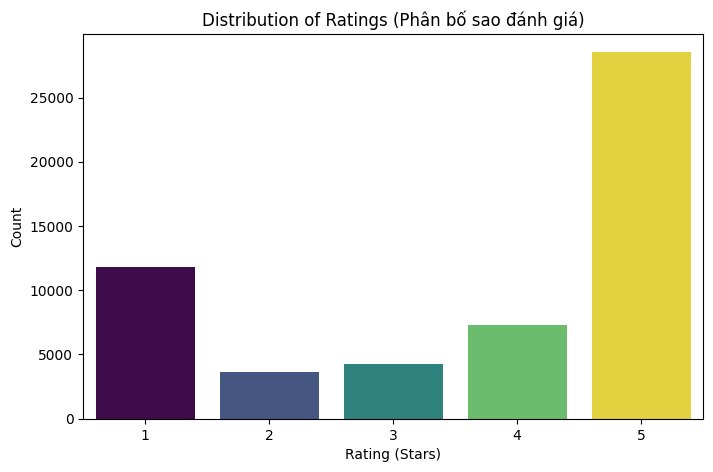

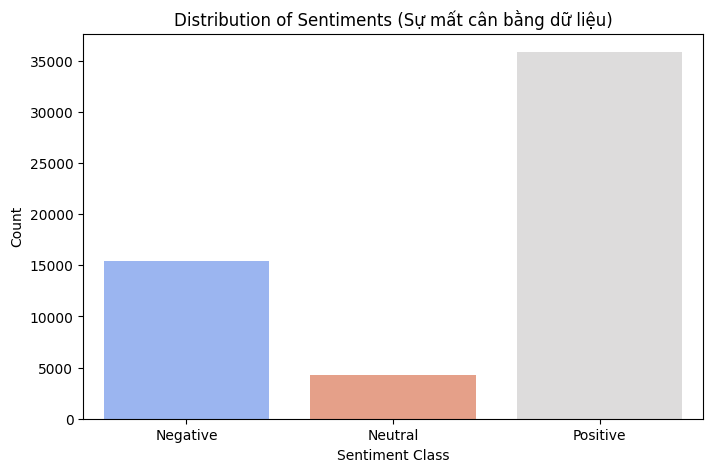


Tỷ lệ phần trăm các lớp cảm xúc:
sentiment
Positive    64.55
Negative    27.74
Neutral      7.71
Name: proportion, dtype: float64


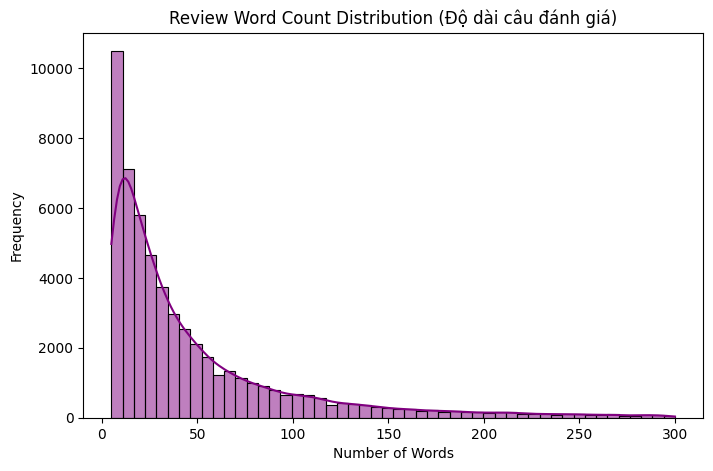

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

print("1. Đang dò tìm đường dẫn và tải dữ liệu...")
file_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if '20191226-reviews.csv' in filename:
            file_path = os.path.join(dirname, filename)
            break

if file_path is None:
    print("LỖI: Trắng tay! Không tìm thấy file. Bạn check lại xem đã Add Data chưa nhé!")
else:
    df_raw = pd.read_csv(file_path)
    
    # ==========================================
    # BƯỚC 1: KHÁM PHÁ DỮ LIỆU THÔ (EDA CƠ BẢN)
    # ==========================================
    print("\n--- THỐNG KÊ DỮ LIỆU BAN ĐẦU ---")
    print(f"Tổng số dòng và cột ban đầu: {df_raw.shape}")
    print("\nKiểm tra dữ liệu thiếu (Null) ở từng cột:")
    print(df_raw.isnull().sum())
    print(f"\nSố lượng dòng bị trùng lặp (Duplicated): {df_raw.duplicated().sum()}")
    
    # ==========================================
    # BƯỚC 2: TIỀN XỬ LÝ & LÀM SẠCH (DATA PREPARATION)
    # ==========================================
    # Xóa duplicate và đổi tên cột
    df_sample = df_raw.drop_duplicates()
    df_sample = df_sample.rename(columns={'body': 'text', 'asin': 'parent_asin', 'name': 'product_name', 'date': 'timestamp'})
    
    # Xóa các dòng bị Null ở 2 cột quan trọng nhất là text và rating
    df_sample = df_sample.dropna(subset=['text', 'rating'])
    print(f"\nSố dòng sau khi làm sạch Null & Duplicated: {df_sample.shape[0]}")

    # Làm sạch văn bản (Clean text)
    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'<.*?>|http\S+|www\S+|[^a-z0-9\s.,!?]', '', text)
        return re.sub(r'\s+', ' ', text).strip()

    df_sample['clean_text'] = df_sample['text'].apply(clean_text)
    
    # Đếm số từ và lọc bỏ review quá ngắn (< 5 từ) hoặc quá dài (> 300 từ)
    df_sample['word_count'] = df_sample['clean_text'].apply(lambda x: len(x.split()))
    df_sample = df_sample[(df_sample['word_count'] >= 5) & (df_sample['word_count'] <= 300)]
    print(f"Số dòng đưa vào huấn luyện (sau khi lọc độ dài câu): {df_sample.shape[0]}")

    # Chuyển Rating thành 3 lớp Sentiment
    def get_sentiment(rating):
        if rating >= 4.0: return 'Positive'
        elif rating == 3.0: return 'Neutral'
        else: return 'Negative'
    df_sample['sentiment'] = df_sample['rating'].apply(get_sentiment)

    # ==========================================
    # BƯỚC 3: TRỰC QUAN HÓA (VISUALIZATION EDA)
    # ==========================================
    print("\n--- VẼ BIỂU ĐỒ TRỰC QUAN ---")
    
    # Biểu đồ 1: Phân bố Rating
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_sample, x='rating', hue='rating', palette='viridis', legend=False)
    plt.title('Distribution of Ratings (Phân bố sao đánh giá)')
    plt.xlabel('Rating (Stars)')
    plt.ylabel('Count')
    plt.show()

    # Biểu đồ 2: Phân bố Sentiment
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_sample, x='sentiment', hue='sentiment', order=['Negative', 'Neutral', 'Positive'], palette='coolwarm', legend=False)
    plt.title('Distribution of Sentiments (Sự mất cân bằng dữ liệu)')
    plt.xlabel('Sentiment Class')
    plt.ylabel('Count')
    plt.show()
    
    # In tỷ lệ phần trăm các lớp cảm xúc
    print("\nTỷ lệ phần trăm các lớp cảm xúc:")
    print(round(df_sample['sentiment'].value_counts(normalize=True) * 100, 2))

    # Biểu đồ 3: Phân bố độ dài câu Review
    plt.figure(figsize=(8, 5))
    sns.histplot(df_sample['word_count'], bins=50, color='purple', kde=True)
    plt.title('Review Word Count Distribution (Độ dài câu đánh giá)')
    plt.xlabel('Number of Words')
    plt.ylabel('Frequency')
    plt.show()